# Scenario Outline

**Scenario**

 An ecommerce company has launched a new recommendation algorithm, which they expect to increase the proportion of recommended items customer's purchase. 

**Hypotheses**

H0: Customers experiencing the new recommendation system will purchase recommended items at the same rate as those experiencing the old recommendation system.

H1: Customers experiencing the new recommendation system will purchase recommended items at a different rate as those experiencing the old recommendation system.

**Statistical Parameters**

*Significance Threshold*: H0 will be rejected at α=0.05

*Practical Significance Threshold*: We will consider an increase of 2% to be practically significant.

*Test Tails*: We will leverage a two tailed test to account for the possibility that the new algorithm decreases the proportion of items users purchase. 

# Power Analysis

In [57]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
import math

In [58]:
# Simulated data -- assume 0.05 of recommended items are purchased.
#                   We expect a 2% increase (indicated in significance parameters), so we expect this rate to increase to 0.07
effect_size = proportion_effectsize(0.05, 0.07)
analysis = NormalIndPower()
sample_size = analysis.solve_power(
    effect_size=effect_size,
    alpha=0.05,
    power=0.80,
    alternative='two-sided'
)

# Round the sample size up to the nearest integer
sample_size = math.ceil(sample_size)
print(f"This experiment will require {sample_size} users per condition")

This experiment will require 2199 users per condition


# Simulate the Data

In [59]:
import numpy as np 
import pandas as pd

In [60]:
# Set the random seed to ensure data is consistent across runs
np.random.seed(42)

In [61]:
# Construct the data
df = {'Group':[], 'Purchased':[]}

# Add control data
df['Group'] += ['Control' for i in range(sample_size)]
df['Purchased'] += np.random.binomial(1, 0.05, sample_size).tolist()

# Add new recommendation system data
df['Group'] += ['Experimental' for i in range(sample_size)]
df['Purchased'] += np.random.binomial(1, 0.055, sample_size).tolist()

df = pd.DataFrame(df)

In [62]:
# Validate the data generation worked
print(f'n Control: {df["Group"].value_counts()["Control"]}')
print(f'n Experimental: {df["Group"].value_counts()["Experimental"]}')
control_mean = df[df["Group"]=="Control"]["Purchased"].describe()["mean"]
experimental_mean = df[df["Group"]=="Experimental"]["Purchased"].describe()["mean"]
print(f'Proportion of Control Group Purchasing Items: {control_mean}')
print(f'Proportion of Experimental Group Purchasing Items: {experimental_mean}')
print(f'Difference in Proportion of Purchased Items: {control_mean - experimental_mean}')

n Control: 2199
n Experimental: 2199
Proportion of Control Group Purchasing Items: 0.05184174624829468
Proportion of Experimental Group Purchasing Items: 0.05411550704865848
Difference in Proportion of Purchased Items: -0.0022737608003638027


# Evaluate the Experiment

In [63]:
# Validate that a parametric test can be used.
n_p_experimental = sample_size * df[df["Group"]=="Experimental"]["Purchased"].describe()["mean"]
n_p_control = sample_size * df[df["Group"]=="Control"]["Purchased"].describe()["mean"]
n_p_inverse_experimental = sample_size * (1-df[df["Group"]=="Experimental"]["Purchased"].describe()["mean"])
n_p_inverse_control = sample_size * (1-df[df["Group"]=="Control"]["Purchased"].describe()["mean"])


if(n_p_control>=10 and n_p_inverse_control>=10 and n_p_experimental>=10 and n_p_inverse_experimental>=10):
    print("A parametric test can be used.")
else:
    print("A non-parametric test should be used.")

A parametric test can be used.


We will evaluate the data using a two-proportion z-test. We can assume the data follows a normal distribution and a parametric test is valid because np and n(1-p) are greater than 10 for both conditions.

In [64]:
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt

In [65]:
# Conduct the two-proportions z-test
control = df[df['Group']=='Control']['Purchased']
experimental = df[df['Group']=='Experimental']['Purchased']
stat, pval = proportions_ztest(count = [control.sum(), experimental.sum()], 
                               nobs = [sample_size, sample_size], 
                               alternative = 'two-sided')
print(f'Statistic: {stat}, p-value: {pval}')

Statistic: -0.33659848231897904, p-value: 0.7364196004453714


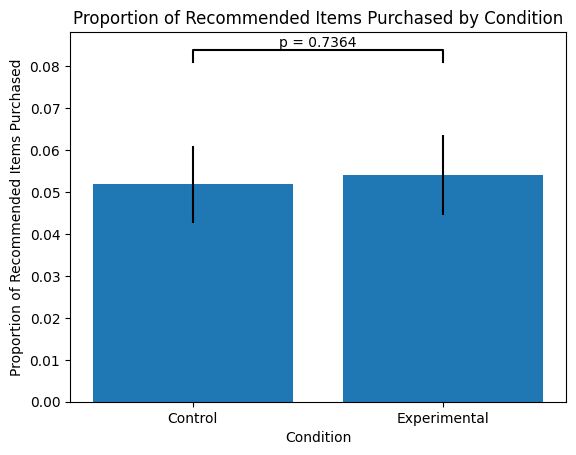

In [66]:
# Visualize the groups
control_se = np.sqrt(control.mean() * (1 - control.mean()) / sample_size)
experimental_se = np.sqrt(experimental.mean() * (1 - experimental.mean()) / sample_size)

# 95% confidence intervals
ci_control = 1.96 * control_se
ci_experimental = 1.96 * experimental_se

# Make the bar charts
fig = plt.bar([1, 2], [control.mean(), experimental.mean()], align='center', yerr=[ci_control, ci_experimental])
plt.xlabel('Condition')
plt.title('Proportion of Recommended Items Purchased by Condition')
plt.xticks([1, 2], ['Control', 'Experimental'])
plt.ylabel('Proportion of Recommended Items Purchased')

# Draw the bracket
x1, x2 = 1, 2 
y = 0.081       
height = 0.003       
plt.plot([x1, x1, x2, x2], [y, y+height, y+height, y], lw=1.5, color='black')
plt.text((x1+x2)/2, y+height, f"p = {round(pval, 4)}", ha='center', va='bottom', fontsize=10)
plt.show()

# Conclusion

We can conclude that the new recommendation system did not result in a significant increase in the proportion of recommended items purchased (z = -0.337, p = 0.7364). We only observe an increase of 0.0.0023 under the new recommendation system, failing to meet the practical significance threshold established early (0.02). A Bonferroni correction is not needed because only one test was conducted.

As such, I recommend that the new recommendation system algorithm not be adopted. 